<a href="https://colab.research.google.com/github/shubhiv02-learner/banking-log-anomaly-detection/blob/main/notebooks/SentinelIQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Install reportlab for PDF generation
!pip install reportlab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.1 MB/s eta 0:00:00


In [136]:
# ============================================================
# SentinelIQ V 0.2
# Statistical Observability Platform
# ============================================================

# This project simulates a banking observability pipeline
# capable of detecting infrastructure anomalies before
# they affect critical financial systems.
#
# Core Techniques Used:
# - EWMA Drift Detection
# - CUSUM Anomaly Detection
# - Persistence Scoring
# - Correlation Analysis
# - Bayesian Incident Prioritization
#
# Author: Shubhi Verma
# Environment: Google Colab / Jupyter Notebook
# ============================================================


# =========================
# STEP 1 — IMPORT LIBRARIES
# =========================

# Pandas -> Data manipulation
# NumPy -> Numerical operations
# PyPlot -> Dashboard visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot
import warnings
import os
import io

warnings.filterwarnings("ignore")
folders = [
    "src",
    "scripts",
    "data/raw",
    "data/processed",
    "outputs"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project structure created.")

Project structure created.


In [104]:
%%writefile scripts/generate_banking_logs.py

# ============================================================
# SentinelIQ V0.2
# Banking Log Generator
# ============================================================

# This script generates realistic structured banking logs
# for anomaly detection and observability experiments.
#
# Simulated Banking Services:
# - payment-api
# - auth-service
# - trading-engine
# - fraud-detection
# - notification-service
#
# Simulated Events:
# - normal requests
# - latency spikes
# - API timeouts
# - database failures
# - queue lag
# - infrastructure saturation
#
# Output:
# data/banking_logs.json
# data/banking_logs.csv
# ============================================================


# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import random
import json
import os
from datetime import datetime, timedelta
import io # Added this import


# =========================
# CREATE OUTPUT DIRECTORY
# =========================

os.makedirs("outputs", exist_ok=True)


# ============================================================
# CONFIGURATION
# ============================================================

TOTAL_LOGS = 15000

START_TIME = datetime(2026, 1, 1)

SERVICES = [
    "payment-api",
    "auth-service",
    "trading-engine",
    "fraud-detection",
    "notification-service",
    "portfolio-service",
    "investment-engine"
]

ENDPOINTS = [
    "/login",
    "/transfer",
    "/payment",
    "/trade",
    "/portfolio",
    "/kyc",
    "/withdrawal"
]

# Map services to their specific endpoints
SERVICE_ENDPOINTS_MAP = {
    "payment-api": ["/payment", "/transfer", "/withdrawal"],
    "auth-service": ["/login", "/kyc"],
    "trading-engine": ["/trade", "/payment", "/transfer"],
    "fraud-detection": ["/kyc", "/payment", "/transfer"],
    "notification-service": ["/login", "/transfer", "/payment"],
    "portfolio-service": ["/portfolio", "/trade"],
    "investment-engine": ["/trade", "/portfolio", "/withdrawal"]
}

# Map services to their base latencies
SERVICE_LATENCY_MAP = {
    "payment-api": 150,
    "auth-service": 80,
    "trading-engine": 100,
    "fraud-detection": 200,
    "notification-service": 70,
    "portfolio-service": 120,
    "investment-engine": 130
}

REGIONS = [
    "India",
    "Singapore",
    "USA",
    "Germany",
    "UAE"
]

STATUS_TYPES = [
    "success",
    "timeout",
    "db_failure",
    "high_latency",
    "queue_delay"
]

# ANOMALY CONFIGURATION: Inject anomalies in three specific windows
ANOMALY_WINDOWS = [
    (int(TOTAL_LOGS * 0.1), int(TOTAL_LOGS * 0.12)), # 10-12% of logs
    (int(TOTAL_LOGS * 0.4), int(TOTAL_LOGS * 0.42)), # 40-42% of logs
    (int(TOTAL_LOGS * 0.7), int(TOTAL_LOGS * 0.72))  # 70-72% of logs
]
ANOMALY_PROB_IN_WINDOW = 0.8  # High probability of anomaly within a window
ANOMALY_PROB_OUT_WINDOW = 0.001 # Low probability of anomaly outside a window

# Define anomaly types and their weights to achieve the desired distribution
anomaly_types_for_selection = ["timeout", "db_failure", "high_latency", "queue_delay"]
anomaly_weights_for_selection = [0.03, 0.01, 0.4, 0.56] # 4% critical, 96% medium

# ============================================================
# GENERATE SINGLE LOG EVENT
# ============================================================

def generate_log_event(index):

    """
    Generates one structured banking log event.

    Simulates:
    - infrastructure metrics
    - service health
    - latency behavior
    - operational failures
    """

    # --------------------------------------------------------
    # Generate timestamp
    # --------------------------------------------------------

    timestamp = START_TIME + timedelta(
        seconds=index * 30
    )

    # --------------------------------------------------------
    # Randomly select banking service and its associated endpoint
    # --------------------------------------------------------

    service = random.choice(SERVICES)
    possible_endpoints = SERVICE_ENDPOINTS_MAP.get(service, ENDPOINTS) # Default to all endpoints if service not in map
    endpoint = random.choice(possible_endpoints)

    region = random.choice(REGIONS)

    # --------------------------------------------------------
    # Generate normal operational metrics with service-specific latency
    # --------------------------------------------------------

    base_latency = SERVICE_LATENCY_MAP.get(service, 120) # Default to 120 if service not in map
    latency_ms = int(
        np.random.normal(base_latency, 20) # Randomize around the base_latency
    )
    cpu_usage = round(np.random.normal(55, 8),2)
    memory_usage = round(np.random.normal(60, 10),2)
    queue_lag = max(0,int(np.random.normal(5, 2)))
    error_code = None
    status = "success"
    severity = "low"
    error_count = 0 # Initialize error_count
    is_anomaly = False # Initialize is_anomaly

    # --------------------------------------------------------
    # Inject anomalies probabilistically based on defined windows
    # --------------------------------------------------------

    in_anomaly_window = False
    for start, end in ANOMALY_WINDOWS:
        if start <= index <= end:
            in_anomaly_window = True
            break

    anomaly_roll = random.random()

    # Determine anomaly probability based on whether the current index is in an anomaly window
    current_anomaly_probability = ANOMALY_PROB_IN_WINDOW if in_anomaly_window else ANOMALY_PROB_OUT_WINDOW

    if anomaly_roll < current_anomaly_probability:
        is_anomaly = True
        # Select anomaly type based on defined weights
        anomaly_type = random.choices(anomaly_types_for_selection, weights=anomaly_weights_for_selection, k=1)[0]

        # =========================================
        # TIMEOUT EVENT
        # =========================================

        if anomaly_type == "timeout":

            latency_ms =max(base_latency+10,int(np.random.normal(base_latency, 100))) # Randomize around the base_latency
            cpu_usage += random.randint(10, 30)
            queue_lag += random.randint(10, 40)
            error_code = "TIMEOUT_ERROR"
            status = "timeout"
            severity = "critical"
            error_count = random.randint(5, 10) # Assign a numerical error count

        # =========================================
        # DATABASE FAILURE
        # =========================================

        elif anomaly_type == "db_failure":

            latency_ms =max(base_latency+10,int(np.random.normal(base_latency, 80))) # Randomize around the base_latency
            cpu_usage += random.randint(5, 20)
            memory_usage += random.randint(10, 20)
            error_code = "DB_CONNECTION_FAILURE"
            status = "db_failure"
            severity = "critical"
            error_count = random.randint(5, 10) # Assign a numerical error count

        # =========================================
        # HIGH LATENCY EVENT
        # =========================================

        elif anomaly_type == "high_latency":
            latency_ms =max(base_latency+30,int(np.random.normal(base_latency, 80))) # Randomize around the base_latency
            queue_lag += random.randint(5, 15)
            error_code = "LATENCY_SPIKE"
            status = "high_latency"
            severity = "medium"
            error_count = random.randint(2, 5) # Assign a numerical error count

        # =========================================
        # QUEUE DELAY EVENT
        # =========================================

        elif anomaly_type == "queue_delay":

            latency_ms =max(base_latency+20,int(np.random.normal(base_latency, 50))) # Randomize around the base_latenc
            queue_lag += random.randint(20, 60)
            error_code = "QUEUE_BACKPRESSURE"
            status = "queue_delay"
            severity = "medium"
            error_count = random.randint(2, 5) # Assign a numerical error count

    # --------------------------------------------------------
    # Create structured log event
    # --------------------------------------------------------
    latency_ms = abs(latency_ms)


    log_event = {

        "timestamp": timestamp.isoformat(),

        "service": service,

        "endpoint": endpoint,

        "region": region,

        "latency_ms": latency_ms,

        "cpu_usage": round(cpu_usage, 2),

        "memory_usage": round(memory_usage, 2),

        "queue_lag": queue_lag,

        "status": status,

        "error_code": error_code,

        "severity": severity,

        "error_count": error_count, # Add error_count to the log event
         "is_anomaly" : is_anomaly
    }

    return log_event


# ============================================================
# GENERATE COMPLETE DATASET
# ============================================================

def generate_banking_logs(total_logs):

    """
    Generates complete banking observability dataset.
    """

    logs = []

    for i in range(total_logs):

        log = generate_log_event(i)

        logs.append(log)

    return logs


# ============================================================
# SAVE LOGS
# ============================================================

def save_logs(logs):

    """
    Saves logs in:
    - JSON format
    - CSV format
    """

    # --------------------------------------------------------
    # Save JSON logs
    # --------------------------------------------------------

    with open(
        "data/banking_logs.json",
        "w"
    ) as f:

        json.dump(
            logs,
            f,
            indent=4
        )

    # --------------------------------------------------------
    # Save CSV logs
    # --------------------------------------------------------

    df = pd.DataFrame(logs)

    df.to_csv(
        "data/banking_logs.csv",
        index=False
    )

    # Capture the statistics output string
    stats_string = display_statistics(df)

    # Define the output file path
    output_file_path = 'outputs/logsStatistics.txt'

    # Ensure the 'outputs' directory exists
    os.makedirs(os.path.dirname(output_file_path), exist_ok=True)

    # Write the captured output to the file
    with open(output_file_path, 'w') as f:
        f.write(stats_string)

    print(f"Log statistics saved to '{output_file_path}'") # Print confirmation here

    return df


# ============================================================
# DISPLAY SAMPLE STATISTICS
# ============================================================

def display_statistics(df):

    """
    Displays dataset overview and anomaly distribution.
    Returns the statistics as a string.
    """
    output_string = io.StringIO()

    output_string.write("\n================================================")
    output_string.write("\n SENTINELIQ LOG GENERATION COMPLETED ")
    output_string.write("\n================================================\n")
    output_string.write(f"\nTotal Logs Generated : {len(df)}\n")
    output_string.write("\nServices Monitored:")
    output_string.write(df['service'].value_counts().to_string())
    output_string.write("\n\nStatus Distribution:")
    output_string.write(df['status'].value_counts().to_string())
    output_string.write("\n\nSeverity Distribution:")
    output_string.write(df['severity'].value_counts().to_string())
    output_string.write("\n\nSample Logs:")
    output_string.write(df.head().to_string())

    # Print to stdout as well for immediate display
    print(output_string.getvalue())
    print("printed sample logs")
    return output_string.getvalue()


# ============================================================
# MAIN DATA GENERATION EXECUTION PIPELINE
# ============================================================

def main():

    print("\nGenerating banking observability logs...\n")

    logs = generate_banking_logs(TOTAL_LOGS)

    df = save_logs(logs)


    print("\nFiles Saved:\n")
    print(f"Banking logs in json saved to outputs/banking_logs.json ")
    print(f"Banking logs in csv format saved to outputs/banking_logs.csv ")
    print(f"Log statistics saved to outputs/logsStatistics.txt")
    print("\nLog generation completed successfully.\n")
    return df

Overwriting scripts/generate_banking_logs.py


In [97]:
%%writefile scripts/call_generate_banking_logs.py
import generate_banking_logs

if __name__ == "__main__":
    df = generate_banking_logs.main()
    print(df.head())


Overwriting scripts/call_generate_banking_logs.py


In [142]:
! python scripts/call_generate_banking_logs.py


Generating banking observability logs...


 SENTINELIQ LOG GENERATION COMPLETED 

Total Logs Generated : 15000

Services Monitored:service
investment-engine       2188
portfolio-service       2165
payment-api             2138
trading-engine          2138
auth-service            2135
fraud-detection         2132
notification-service    2104

Status Distribution:status
success         14252
queue_delay       434
high_latency      284
timeout            29
db_failure          1

Severity Distribution:severity
low         14252
medium        718
critical       30

Sample Logs:             timestamp               service    endpoint     region  latency_ms  cpu_usage  memory_usage  queue_lag   status error_code severity  error_count  is_anomaly
0  2026-01-01T00:00:00          auth-service        /kyc    Germany          80      58.33         65.40          3  success       None      low            0       False
1  2026-01-01T00:00:30          auth-service        /kyc  Singapore         106 

In [139]:
%%writefile src/generate_banking_logs_metrics.py
import pandas as pd
import numpy as np

SERVICE_LATENCY_MAP = {
    "payment-api": 150,
    "auth-service": 80,
    "trading-engine": 100,
    "fraud-detection": 200,
    "notification-service": 70,
    "portfolio-service": 120,
    "investment-engine": 130
}
# ============================================================
# STEP 3 — EWMA DRIFT DETECTION
# ============================================================

def apply_ewma_detection(df, alpha=0.3):

    """
    Applies EWMA anomaly detection.

    EWMA helps detect gradual operational drift
    before systems cross critical thresholds.

    Parameters:
    -----------
    df : pandas.DataFrame
        Banking observability dataset

    alpha : float
        EWMA smoothing factor
        typically between 0 and 1, which dictates how quickly the average adapts to new data
        Higher the value it reacts faster to recent changes

    Returns:
    --------
    df : pandas.DataFrame
        Updated dataframe with EWMA metrics

    threshold : float
        Dynamic anomaly threshold
    """
    # Compute EWMA latency trend based on raw latency_ms (for plotting compatibility)
    df['ewma_latency'] = (round(df['latency_ms'].ewm(alpha=alpha).mean(),2))

    # Dynamic anomaly threshold for raw latency (for dashboard plotting purposes)
    raw_latency_plot_threshold = (df['ewma_latency'].mean()+ 2*df['ewma_latency'].std())

    # Calculate expected base latency for each service
    df['expected_base_latency'] = df['service'].map(SERVICE_LATENCY_MAP)

    # Calculate latency deviation from the expected base latency
    df['latency_deviation'] = df['latency_ms'] - df['expected_base_latency']
    df['latency_deviation'] = df['latency_deviation'].abs()
    # Compute EWMA latency deviation trend for actual anomaly detection
    df['ewma_latency_deviation_for_alert'] = (round(df['latency_deviation'].ewm(alpha=alpha).mean(),2))

    # Dynamic anomaly threshold based on deviation for alerting
    # The mean of ewma_latency_deviation_for_alert should ideally be close to 0 if the system is stable.
    deviation_alert_threshold = (
        df['ewma_latency_deviation_for_alert'].abs().mean()+2 * df['ewma_latency_deviation_for_alert'].std()
        )
    print(f"Raw Latency Plot Threshold (for dashboard): {raw_latency_plot_threshold}")
    print(f"Deviation Alert Threshold (for detection): {deviation_alert_threshold}")
    # Flag anomalous drift regions based on deviation
    df['ewma_alert'] = (
        (df['ewma_latency_deviation_for_alert'].abs() > deviation_alert_threshold)
    )

    print("EWMA detection completed.\n")
    print(f"Raw Latency Plot Threshold (for dashboard): {raw_latency_plot_threshold}")
    print(f"Deviation Alert Threshold (for detection): {deviation_alert_threshold}")
    return df, raw_latency_plot_threshold # Return the threshold for raw latency for dashboard compatibility


# ============================================================
# STEP 4 — CUSUM DETECTION
# ============================================================

def apply_cusum_detection(df):

    """
    Applies CUSUM detection.

    CUSUM identifies cumulative deviations
    from normal operational behavior.

    Useful for:
    - silent degradation
    - queue accumulation
    - sustained instability
    """
    # Ensure latency_deviation is available (compute if not already)
    if 'latency_deviation' not in df.columns:
        df['expected_base_latency'] = df['service'].map(SERVICE_LATENCY_MAP)
        df['latency_deviation'] = df['latency_ms'] - df['expected_base_latency']


    mu = df['latency_deviation'].std()
    k = mu * 0.5
    print(f"CUSUM Smoothing Factor (k): {k}")
    h = mu*6
    print(f"CUSUM Alert Threshold (for detection): {h}")

    # Target for deviation
    target = 10 # Retaining 10 as in the original code

    cusum_values = []
    current_cusum_sum = 0.0 # Initialize cumulative sum for each day
    # Convert timestamp to datetime if not already (good for plotting)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['logdate'] = df['timestamp'].dt.date # Add logdate column

    if not df.empty:
        prev_date = df['timestamp'].iloc[0].date()
    else:
        print("DataFrame is empty, cannot apply CUSUM detection.")
        return df

    for i in range(len(df)):
        current_date = df['logdate'].iloc[i]
        latency_dev = df['latency_deviation'].iloc[i]

        if current_date != prev_date:
            # Date has changed, reset the CUSUM sum for the new day
            current_cusum_sum = 0.0
            prev_date = current_date
            print(f'CUSUM Reset on {current_date}')

        # Calculate CUSUM for the current point
        current_cusum_sum = round(max(0.0, current_cusum_sum + (latency_dev - target - k)), 2)
        cusum_values.append(current_cusum_sum)

    df['cusum'] = cusum_values

    # Alert threshold
    df['cusum_alert'] = (df['cusum'] > h)

    print("CUSUM detection completed.\n")

    return df


# ============================================================
# STEP 5 — PERSISTENCE SCORING
# ============================================================

def calculate_persistence_score(df):

    """
    Measures anomaly persistence duration.

    Persistent anomalies are treated as
    higher operational risks than isolated spikes.
    """

    # Combine anomaly signals
    df['combined_alert'] = (
        df['ewma_alert'] | df['cusum_alert']
    )

    persistence = []

    count = 0

    for val in df['combined_alert']:
        if val:
            count += 1
        else:
            count = 0

        persistence.append(count)

    df['persistence_score'] = persistence

    print("Persistence scoring completed.\n")

    return df


# ==================================
# STEP 6 — CORRELATION ANALYSIS
# ==================================

def generate_correlation_analysis(df):

    correlation = df[
        [
            'latency_ms',
            'error_count',
            'cpu_usage',
            'persistence_score',
            'incident_probability'

        ]
    ].corr().round(2)

    print("\nCorrelation Matrix:\n")
    print(correlation)

    return correlation


# ============================================
# STEP 7 — BAYESIAN PRIORITIZATION
# ============================================

def apply_bayesian_prioritization(df):
    import pandas
    df['incident_probability'] = (round(

        0.4 * (
            df['persistence_score'] / df['persistence_score'].max()
        )

        +

        0.3 * (
            df['error_count']/df['error_count'].max()
        )

        +

        0.3 * (
            df['cpu_usage']/df['cpu_usage'].max()
        ), 2)
    )

    df['priority'] = pandas.cut(

        df['incident_probability'],

        bins=[0, 0.3, 0.5, 0.7,1],

        labels=[
            'Low',
            'Medium',
            'High',
            'Critical'
        ]
    )

    df['priority'] = df['priority'].astype(str)


    return df

Overwriting src/generate_banking_logs_metrics.py


In [101]:
%%writefile src/generate_analysis.py
SERVICE_LATENCY_MAP = {
    "payment-api": 150,
    "auth-service": 80,
    "trading-engine": 100,
    "fraud-detection": 200,
    "notification-service": 70,
    "portfolio-service": 120,
    "investment-engine": 130
}
# ==================================
# STEP 8 — EXECUTIVE DASHBOARD
# ==================================

def generate_dashboard(df, threshold):
    import matplotlib.pyplot as pyplot
    import pandas as pd # Import pandas here for to_datetime

    # Convert timestamp to datetime if not already (good for plotting)
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Plot the latency data
    pyplot.figure(figsize=(14,6))

    pyplot.plot(
        df['timestamp'],
        df['latency_deviation'],
        label='Adjusted Latency per service'
    )

    pyplot.plot(
        df['timestamp'],
        df['ewma_latency_deviation_for_alert'],
        label='EWMA'
    )

    critical_df = df[df['priority'] == 'Critical']
    high_df = df[df['priority'] == 'High']

    # Plot critical incidents as scatter points on the latency axis
    pyplot.scatter(
        critical_df['timestamp'],
        critical_df['latency_deviation'], # Plot latency at critical incidents
        color='purple',
        marker='X', # Use 'X' marker for critical incidents
        s=100, # Size of the marker
        label='Critical Incidents'
    )

    pyplot.axhline(
        threshold,
        color='red',
        linestyle='--',
        label='Threshold'
    )

    pyplot.title(
        "SentinelIQ Banking System Monitoring"
    )

    pyplot.xlabel("Timestamp")

    pyplot.ylabel("Adjusted Latency per service(ms)")

    pyplot.legend()

    pyplot.grid(True)

    pyplot.xticks(rotation=45)

    pyplot.savefig("outputs/latency_chart.png")

    pyplot.show()


# ==================================
# STEP 9 — EXECUTIVE SUMMARY
# ==================================

def generate_executive_summary(df):

    critical_count = (
        df['priority'] == 'Critical').sum()

    high_count = (
        df['priority'] == 'High').sum()
    medium_count = (
        df['priority'] == 'Medium').sum()


    summary = f"""

    SENTINELIQ OPERATIONAL SUMMARY
    --------------------------------
    Total Incidents : {len(df)}
    Critical Incidents : {critical_count}
    High Incidents   : {high_count}
    Medioum Incidents   : {medium_count}

    Observations:
    - Sustained latency degradation detected
    - Infrastructure pressure increasing
    - Multiple correlated anomaly windows identified

    Recommended Action:
    Investigate payment processing systems
    and infrastructure resource utilization.

    """
    print(summary)

    return summary


def write_pdf_report(file_path, content):
    from reportlab.platypus import SimpleDocTemplate
    from reportlab.lib.pagesizes import letter

    pdf = SimpleDocTemplate(
        file_path,
        pagesize=letter,
        rightMargin=40,
        leftMargin=40,
        topMargin=40,
        bottomMargin=30
    )
    pdf.build(content)
    print(f"PDF generated successfully: {file_path}")

def generate_executive_summary_report(df):
    from reportlab.platypus import (Paragraph, Spacer, Image)
    from reportlab.lib.styles import getSampleStyleSheet
    from reportlab.lib import colors
    from reportlab.platypus.flowables import HRFlowable

    # ============================================================
    # PDF REPORT GENERATION
    # ============================================================

    pdf_file = "outputs/banking_anomaly_report.pdf"

    styles = getSampleStyleSheet()
    content = []

    # ============================================================
    # TITLE
    # ============================================================

    content.append(Paragraph(
        "<b>SentinelIQ Banking Anomaly Detection Report</b>",
        styles['Title']
    ))

    content.append(Spacer(1, 20))

    # ============================================================
    # EXECUTIVE SUMMARY
    # ============================================================

    content.append(Paragraph(
        "<b>Executive Summary</b>",
        styles['Heading1']
    ))

    Total_count = len(df)
    critical_count = ( df['priority'] == 'Critical').sum()
    high_count = ( df['priority'] == 'High').sum()
    medium_count = ( df['priority'] == 'Medium').sum()

    content.append(Paragraph(
        "<b>SENTINELIQ OPERATIONAL SUMMARY</b>",
        styles['Heading2']
    ))
    summary = f"""

    \n\n

    Total Incidents : {Total_count}\n
    Critical Incidents : {critical_count}\n
    High Incidents   : {high_count}\n
    Medium Incidents   : {medium_count}\n\n

    """
    executive_summary_text = """
    This report provides an overview of simulated banking logs,
    observed anomalies, service failures, and system health metrics.

    Key findings include:

    • Increased authentication failures during peak traffic.
    • Elevated fraud detection alerts from payment-api.
    • Trading-engine latency spikes observed intermittently.
    • Isolation Forest identified suspicious transaction patterns.

    Overall system stability remained acceptable, though multiple
    high-severity anomalies require operational review.
    """
    summary = summary + executive_summary_text
    print(summary)
    content.append(Paragraph(summary, styles['BodyText']))

    content.append(Spacer(1, 15))

    # Horizontal line
    content.append(HRFlowable(width="100%", color=colors.grey))
    content.append(Spacer(1, 15))

    # ============================================================
    # PNG IMAGE / CHART
    # ============================================================

    content.append(Paragraph(
        "<b>Anomaly Trend Visualization</b>",
        styles['Heading2']
    ))

    # PNG image path
    image_path = "outputs/latency_chart.png"

    # Add image
    img = Image(image_path, width=450, height=250)
    content.append(img)

    content.append(Spacer(1, 20))

    # ============================================================
    # SAMPLE TABLE (Commented out in original, keeping it that way)
    # ============================================================

    content.append(Paragraph(
        "<b>Service Error Summary</b>",
        styles['Heading2']
    ))
    """
    # Example table data
    service_data = [
        ["Service", "Error Count", "Severity"],
        ["payment-api", "42", "High"],
        ["auth-service", "31", "Medium"],
        ["fraud-detection", "15", "Critical"],
        ["trading-engine", "22", "High"]
    ]

    # Create table
    service_table = Table(service_data, colWidths=[180, 120, 120])

    # Table styling
    service_table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.darkblue),
        ('TEXTCOLOR', (0, 0), (-1, 0), colors.white),
        ('GRID', (0, 0), (-1, -1), 1, colors.black),
        ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
        ('BOTTOMPADDING', (0, 0), (-1, 0), 10),
        ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
    ]))

    content.append(service_table)

    content.append(Spacer(1, 25))
    """
    # ============================================================
    # ADDITIONAL INSIGHTS
    # ============================================================

    content.append(Paragraph(
        "<b>Observations</b>",
        styles['Heading1']
    ))

    observations = """
    The anomaly distribution indicates that most failures originated
    from authentication and payment processing systems.

    The fraud-detection service generated fewer events but showed
    higher severity anomalies.

    Further monitoring and alert correlation is recommended.
    """

    content.append(Paragraph(observations, styles['BodyText']))

    # ============================================================
    # BUILD PDF
    # ============================================================
    write_pdf_report(pdf_file, content)

    return

Overwriting src/generate_analysis.py


In [129]:
%%writefile src/run_logs.py
import pandas as pd
import json

import generate_banking_logs_metrics as banking_utils
import generate_analysis as analysis_utils

# Load the banking_logs.csv file into a DataFrame
df = pd.read_csv('data/banking_logs.csv')

print("Loaded 'data/banking_logs.csv' into 'df'.")

# Display the first 5 rows of the DataFrame
print(df.head())

print("Applying EWMA Detection...\n")
df, threshold = banking_utils.apply_ewma_detection(df)

print("Applying CUSUM Detection...\n")
df = banking_utils.apply_cusum_detection(df)

print("Calculating Persistence Scores...\n")
df = banking_utils.calculate_persistence_score(df)

print("Applying Bayesian Prioritization...\n")
df = banking_utils.apply_bayesian_prioritization(df)

print("Running Correlation Analysis...\n")
correlation = banking_utils.generate_correlation_analysis(df)

# Display the first 5 rows of the DataFrame after metrics updation
print(df.head())

print("Generating Monitoring Dashboard...\n")
analysis_utils.generate_dashboard(df, threshold)

print("Generating Executive Summary...\n")
summary = analysis_utils.generate_executive_summary(df)
analysis_utils.generate_executive_summary_report(df)
# Save outputs
df.to_csv(
        "outputs/sentineliq_results.csv",
        index=False
    )

print("Output with metrics saved to outputs/sentineliq_results.csv ")
with open('outputs/executive_summary.txt', 'w') as f:
      f.write(summary)

print("Executive summary saved to 'outputs/executive_summary.txt'")
print("\nPipeline Execution Completed.\n")

Overwriting src/run_logs.py


In [143]:
! python src/run_logs.py

Loaded 'data/banking_logs.csv' into 'df'.
             timestamp               service  ... error_count is_anomaly
0  2026-01-01T00:00:00          auth-service  ...           0      False
1  2026-01-01T00:00:30          auth-service  ...           0      False
2  2026-01-01T00:01:00  notification-service  ...           0      False
3  2026-01-01T00:01:30     investment-engine  ...           0      False
4  2026-01-01T00:02:00           payment-api  ...           0      False

[5 rows x 13 columns]
Applying EWMA Detection...

Raw Latency Plot Threshold (for dashboard): 163.74638558620805
Deviation Alert Threshold (for detection): 30.63073011672778
EWMA detection completed.

Raw Latency Plot Threshold (for dashboard): 163.74638558620805
Deviation Alert Threshold (for detection): 30.63073011672778
Applying CUSUM Detection...

CUSUM Smoothing Factor (k): 6.985543928590403
CUSUM Alert Threshold (for detection): 83.82652714308483
CUSUM Reset on 2026-01-02
CUSUM Reset on 2026-01-03
CUSUM Rese

# Stage 2
Load data and do pre processing

In [115]:
import pandas as pd

df = pd.read_csv('outputs/sentineliq_results.csv')

print("Loaded 'outputs/sentineliq_results.csv' into 'results_df'.")
print(df.head())
count = df.duplicated().sum()
print(f'duplicate rows {count}')
print(df.info())

print(df.describe().T)

Loaded 'outputs/sentineliq_results.csv' into 'results_df'.
             timestamp               service   endpoint   region  latency_ms  \
0  2026-01-01 00:00:00  notification-service   /payment    India          79   
1  2026-01-01 00:00:30          auth-service     /login    India          88   
2  2026-01-01 00:01:00  notification-service   /payment  Germany          64   
3  2026-01-01 00:01:30        trading-engine     /trade  Germany          87   
4  2026-01-01 00:02:00       fraud-detection  /transfer      UAE         187   

   cpu_usage  memory_usage  queue_lag   status error_code  ...  \
0      59.92         27.38          2  success        NaN  ...   
1      60.30         82.05          4  success        NaN  ...   
2      59.65         87.10          2  success        NaN  ...   
3      44.19         55.12          1  success        NaN  ...   
4      57.54         54.35          7  success        NaN  ...   

  expected_base_latency  latency_deviation  ewma_latency_deviat

In [ ]:
desc = pd.DataFrame(index = list(df)) #create Rows with columns of orginal dataframe
desc['type'] = df.dtypes
desc['count'] = df.count()
desc['nunique'] = df.nunique()
desc['%unique'] = desc['nunique'] /len(df) * 100
desc['null'] = df.isnull().sum()
desc['%null'] = desc['null'] / len(df) * 100
desc = pd.concat([desc,df.describe().T.drop('count',axis=1)],axis=1)
desc.sort_values(by=['type','null']).style.background_gradient(cmap='YlOrBr')\
    .bar(subset=['mean'],color='green')\
    .bar(subset=['max'],color='red')\
    .bar(subset=['min'], color='pink').to_excel("outputs/Sentinel_preprocess.xlsx")

In [ ]:
# Get a list of categorical columns in the dataframe
categorical_columns = df.select_dtypes(include=['object']).columns

# Check the unique values and their counts for each categorical column
for col in categorical_columns:
    print(f"Column: {col}")
    print("-" * 25)
    print(f"Unique values: {df[col].nunique()}")
    print(f"Unique values sample: {df[col].unique()[:10]}")  # Display a sample of unique values
    print("-" * 50)

**Applying Isolation Forest for Anomaly Detection**
This section applies the Isolation Forest algorithm, an unsupervised learning method, to detect anomalies in the banking logs. Isolation Forest works by isolating anomalies rather than profiling normal data points, which makes it efficient and effective for high-dimensional datasets. The model will identify data points that are 'different' from the majority, flagging them as potential anomalies.

In [ ]:
from sklearn.ensemble import IsolationForest


print("Applying Isolation Forest Detection...\n")

# Define features for Isolation Forest
features = df[
    [
        "latency_ms",
        "cpu_usage",
        "memory_usage",
        "queue_lag"
    ]
]

""""""""""""""""
# Initialize Isolation Forest model
model = IsolationForest(
    contamination=0.05, # Approximate proportion of anomalies in the dataset
    random_state=42
)

# Fit the model and make predictions
model.fit(features)
predictions = model.predict(features)

# Add Isolation Forest anomaly predictions to the DataFrame
df["ml_anomaly"] = predictions

# Convert predictions to a more intuitive anomaly flag (1 for anomaly, 0 for normal)
df['ml_anomaly'] = df['ml_anomaly'].apply(lambda x: 1 if x == -1 else 0)

print("Isolation Forest detection completed.\n")
"""

### [Stage 3 EDA]

No numerical column is Null

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression


### KDE Plot for Incident Probability with Thresholds

This plot visualizes the distribution of the `incident_probability` column. Regions where the probability is above 0.5 are highlighted in red, and regions above 0.6 are further highlighted in purple, allowing for quick identification of higher-risk probability ranges.

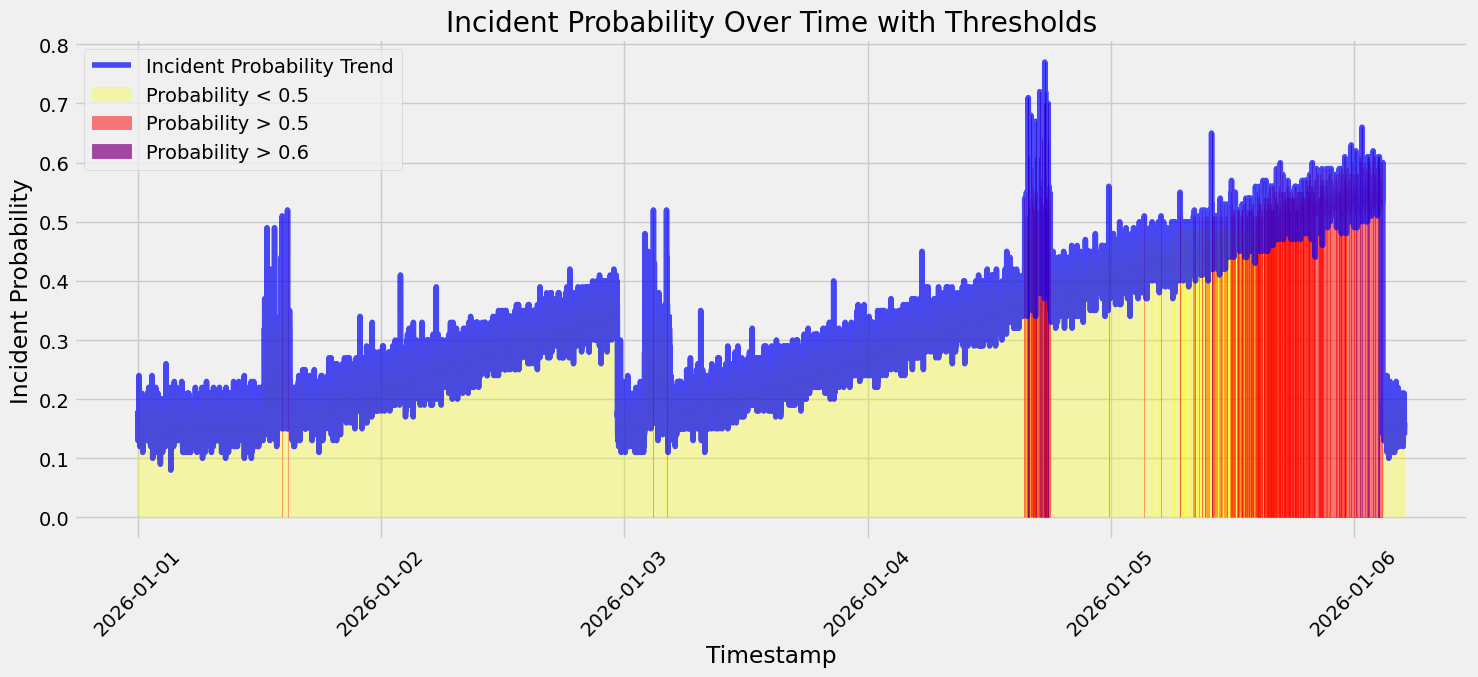

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Ensure timestamp is in datetime format for plotting
df['timestamp'] = pd.to_datetime(df['timestamp'])

plt.figure(figsize=(15, 7))

# Plot the incident probability over time
plt.plot(df['timestamp'], df['incident_probability'], color='blue', label='Incident Probability Trend', alpha=0.7)

# Get data for fill_between
x_values = df['timestamp']
y_values = df['incident_probability']

# Fill the area for incident_probability < 0.5 (yellow)
plt.fill_between(x_values, y_values, where=(y_values < 0.5), color='yellow', alpha=0.3, label='Probability < 0.5')

# Fill the area for incident_probability > 0.5 (red)
plt.fill_between(x_values, y_values, where=(y_values > 0.5), color='red', alpha=0.5, label='Probability > 0.5')

# Fill the area for incident_probability > 0.6 (purple). This will overlap the red in that region.
plt.fill_between(x_values, y_values, where=(y_values > 0.6), color='purple', alpha=0.7, label='Probability > 0.6')

plt.title('Incident Probability Over Time with Thresholds')
plt.xlabel('Timestamp')
plt.ylabel('Incident Probability')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.savefig("outputs/incident_probability_time_series.png", bbox_inches="tight")
plt.close() # Close the plot to free up memory

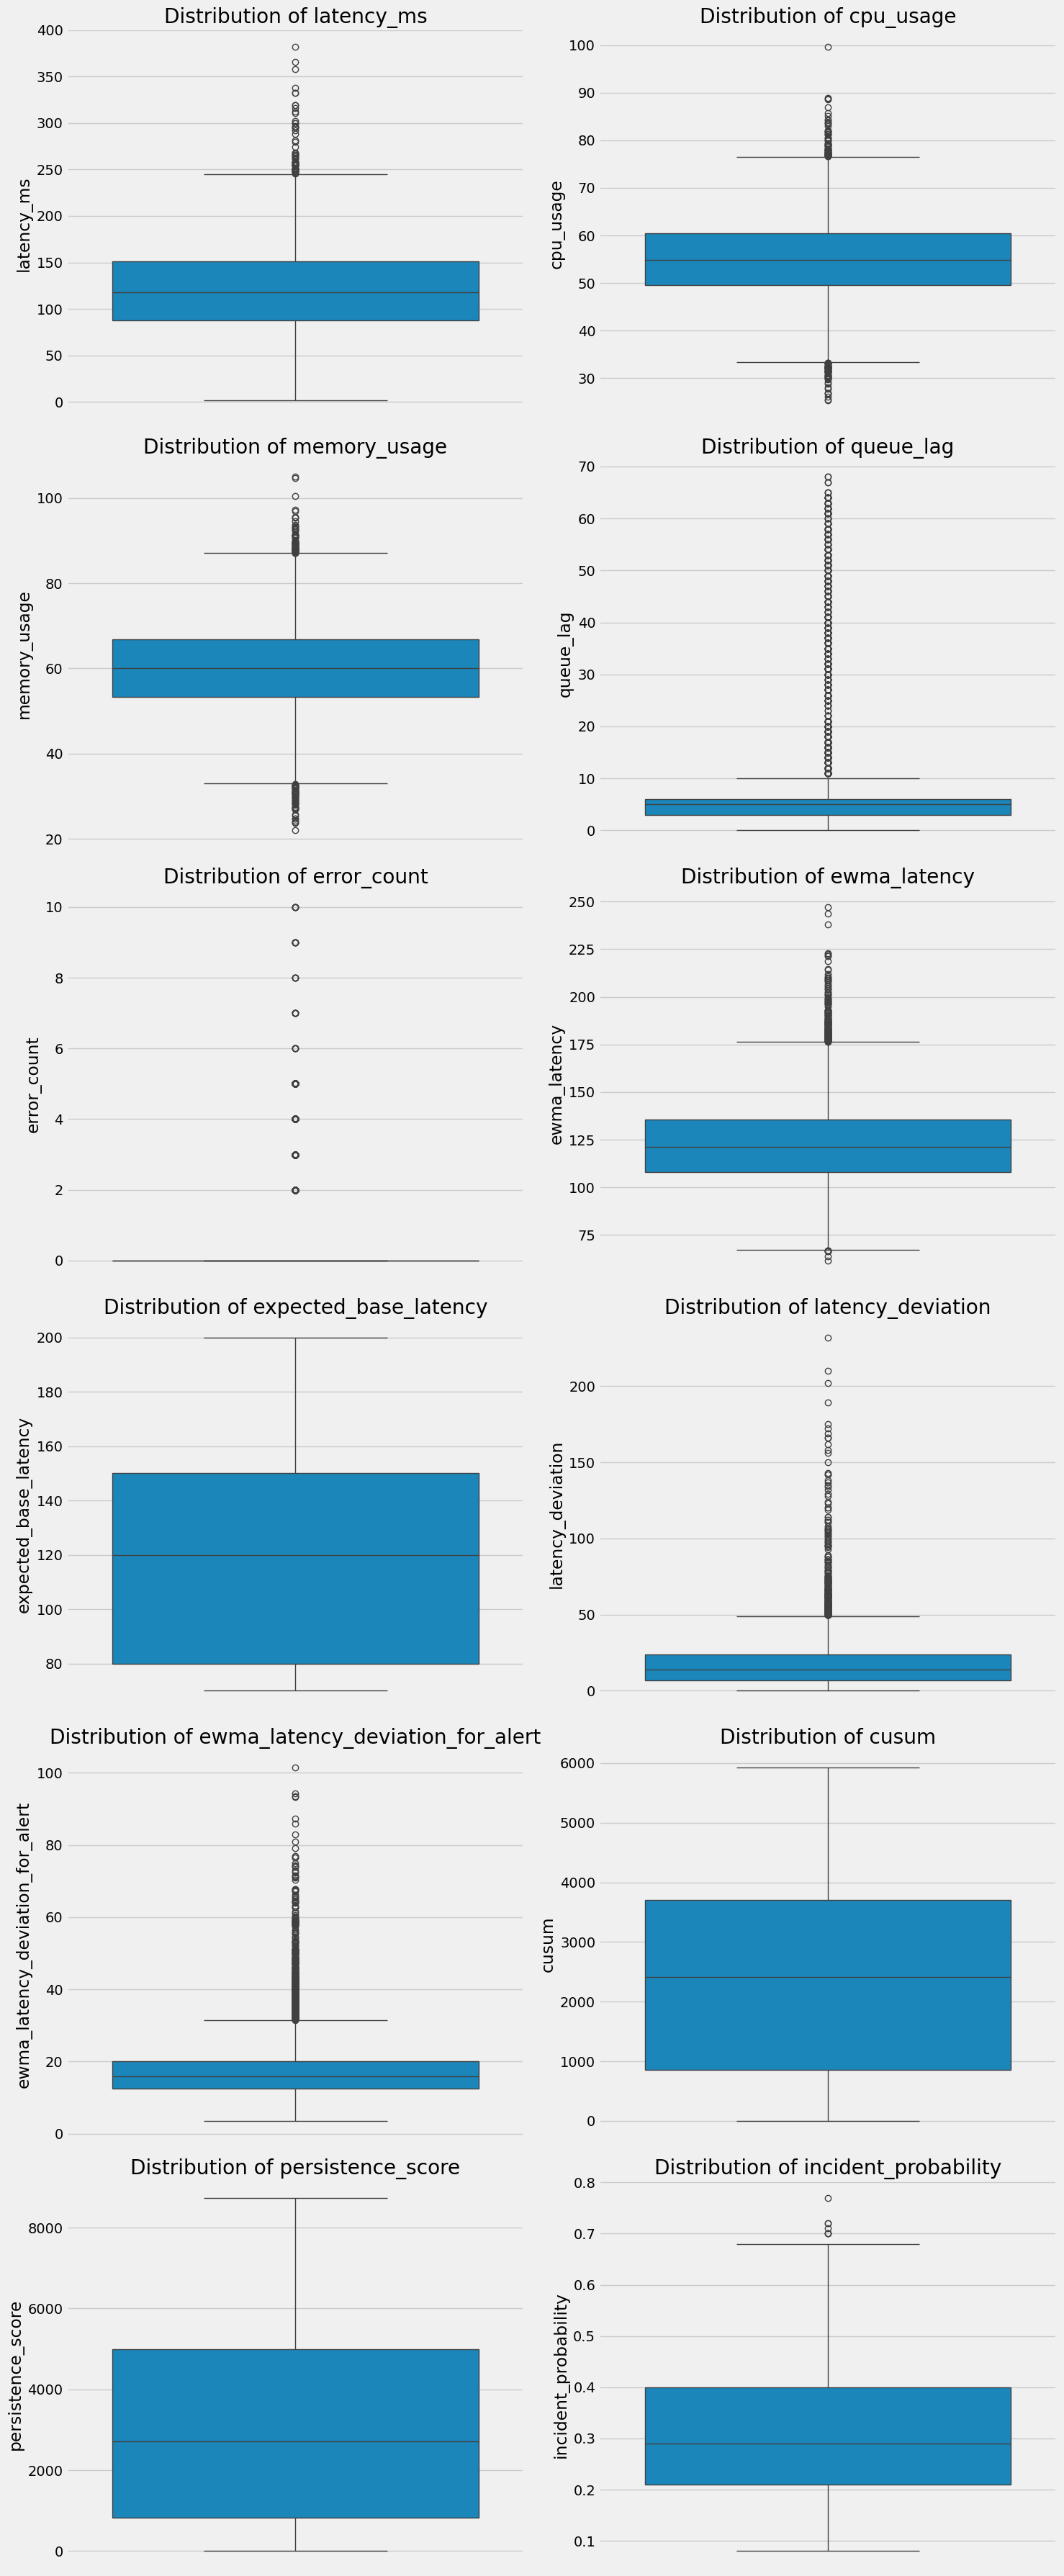

In [119]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for all plots in this cell
plt.style.use("fivethirtyeight")

# Assume numerical_columns is defined from a previous cell. If not, re-define it here:
numerical_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Calculate the number of rows and columns for the subplots
num_cols_for_plot = 2 # Number of charts per row
num_rows_for_plot = (len(numerical_columns) + num_cols_for_plot - 1) // num_cols_for_plot

fig, axes = plt.subplots(num_rows_for_plot, num_cols_for_plot, figsize=(15, 6 * num_rows_for_plot))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, col in enumerate(numerical_columns):
    # Create the boxplot vertically on the current subplot
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel(col) # Set y-label as it's a vertical boxplot

# Hide any unused subplots if the number of numerical columns is not a perfect multiple of num_cols_for_plot
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()

# Save the entire figure
plt.savefig("box_plots_all_numerical.png", bbox_inches="tight")
plt.close() # Closes the plot window to save memory

In [121]:
# For categorical columns, we'll fill missing values with the mode (most frequent category)
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print(categorical_columns)

Index(['service', 'endpoint', 'region', 'status', 'error_code', 'severity',
       'priority'],
      dtype='object')


EDA for categorical columns

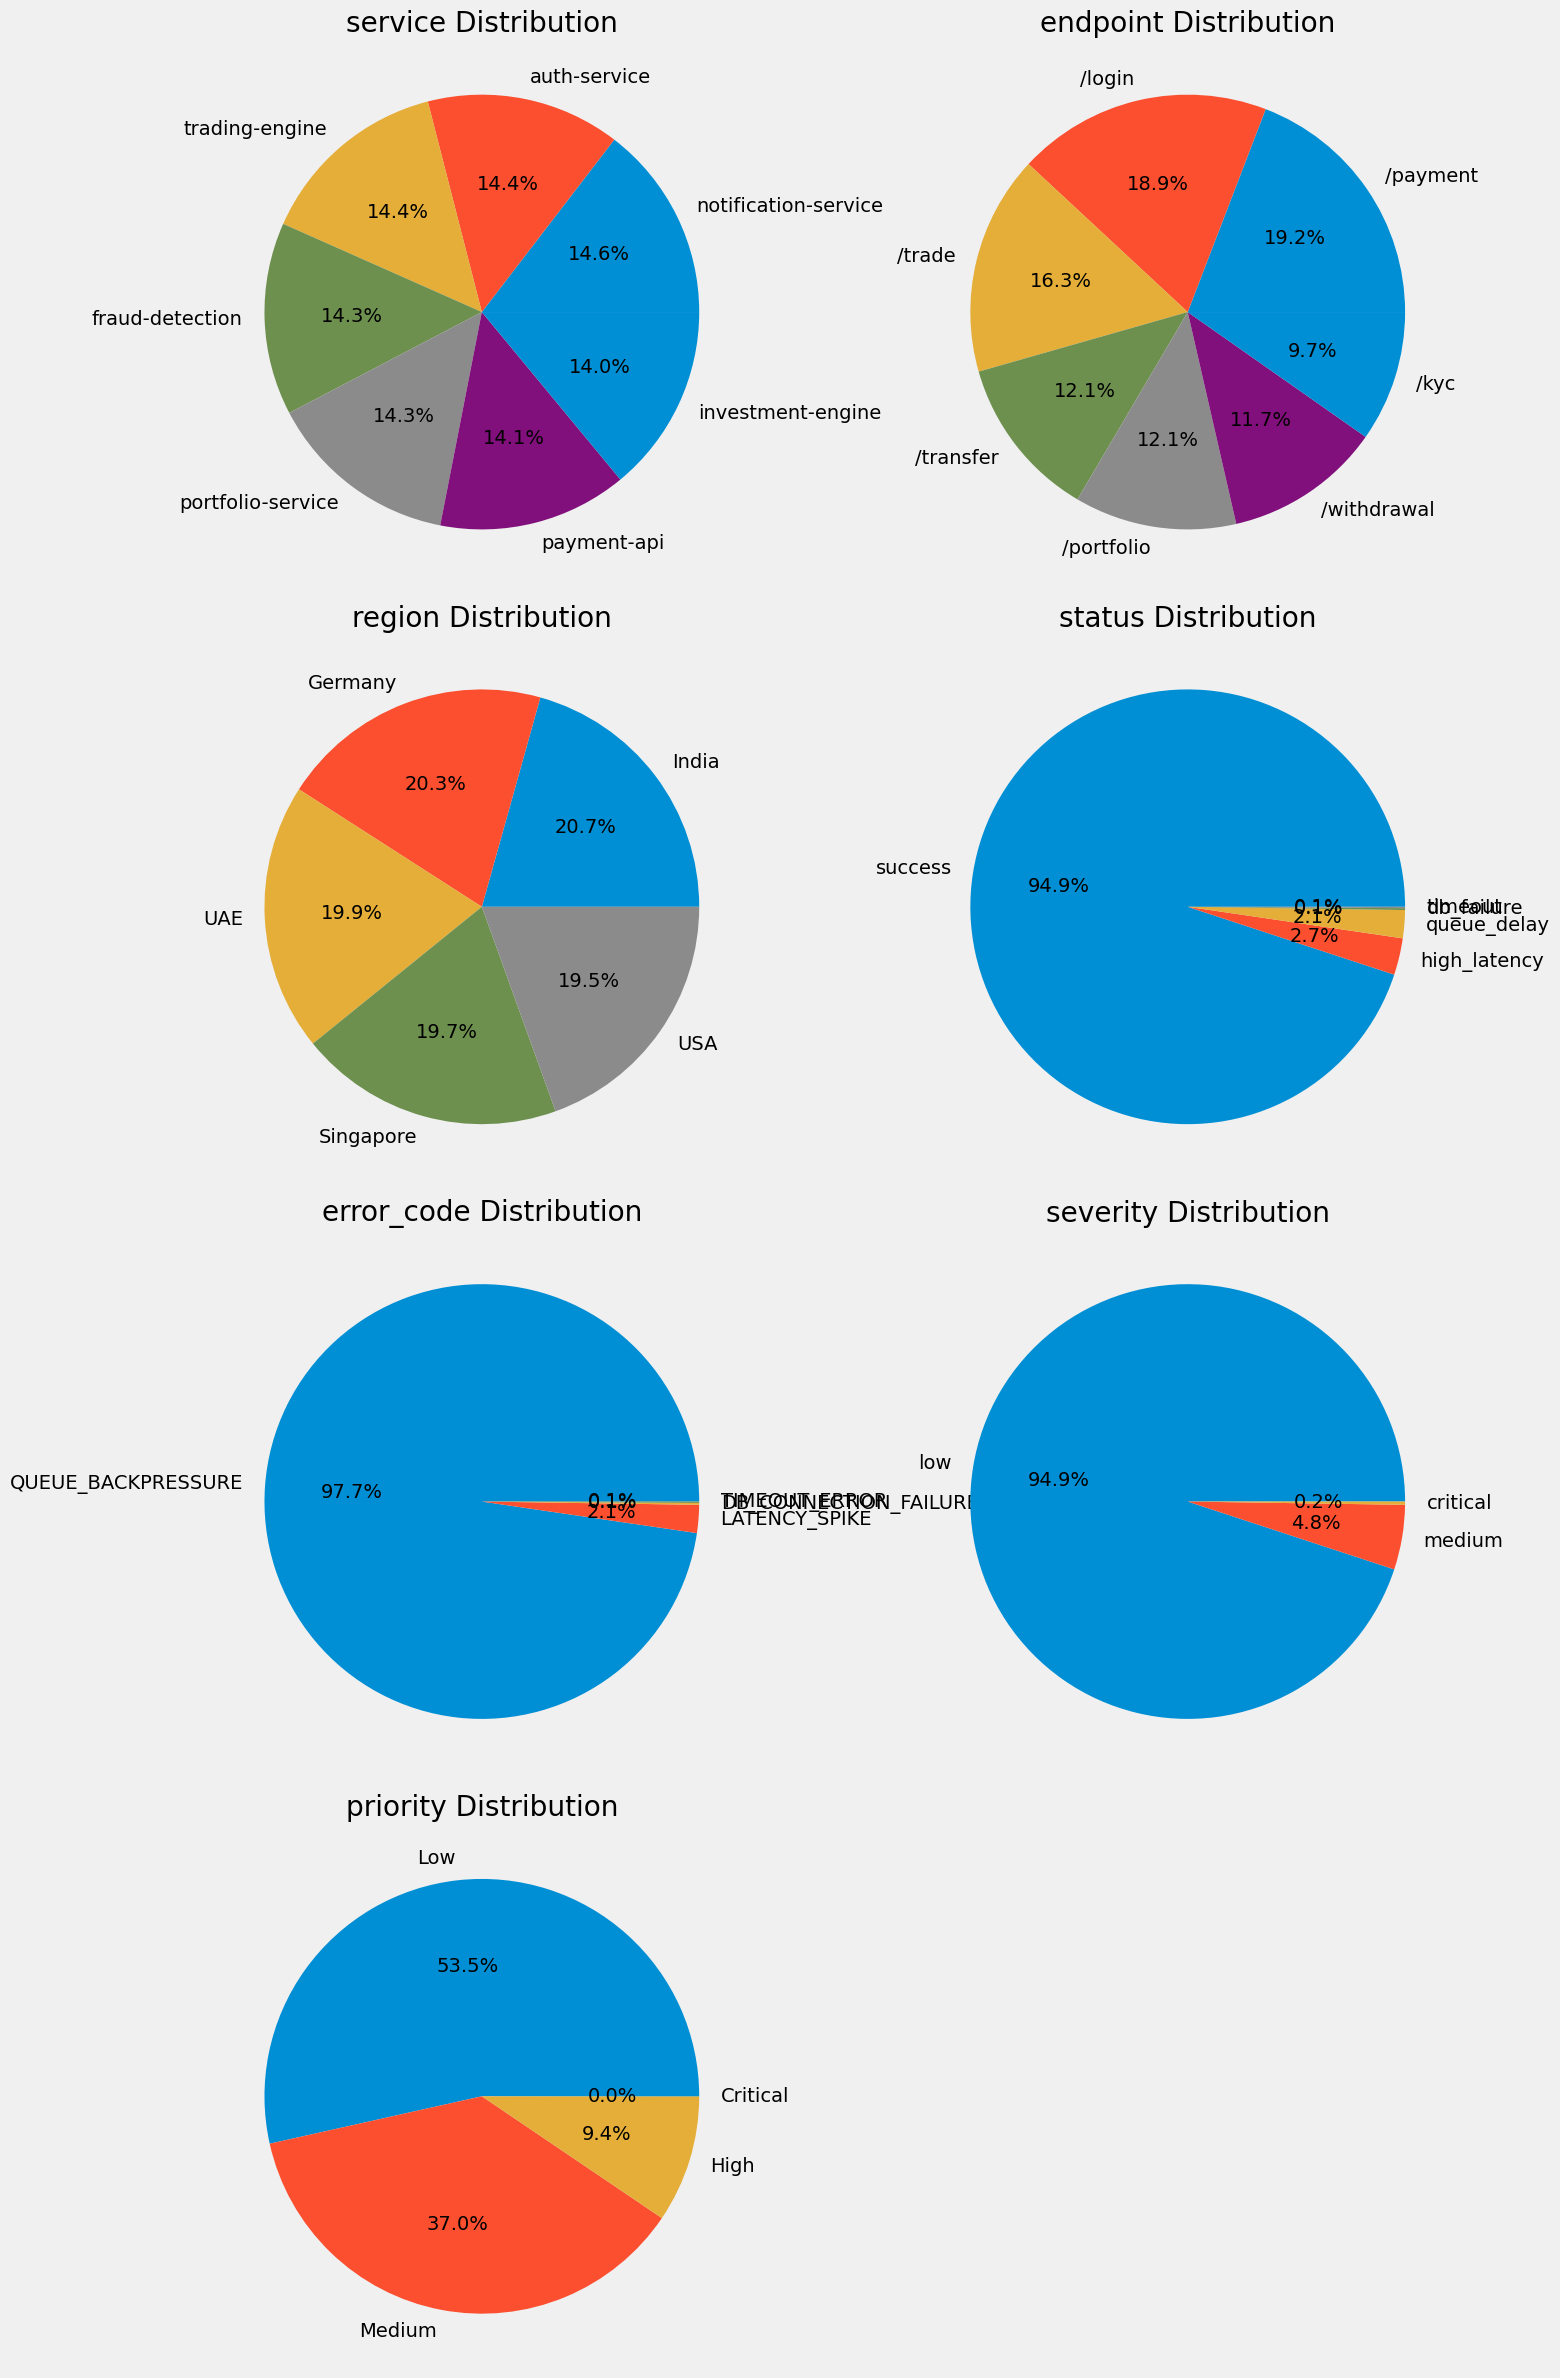

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter categorical columns to include only those with less than 10 unique values
# These are the columns we will actually plot.
plot_categorical_columns = [col for col in categorical_columns if df[col].nunique() < 10]

# Calculate the number of rows needed based on the number of charts to plot
num_cols = 2  # Number of charts per row
num_rows = (len(plot_categorical_columns) + num_cols - 1) // num_cols  # Dynamically calculate rows

# Create the figure and axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 6))  # Adjust figure size for more rows

# Flatten the axes array for easier iteration, handling the case of a single row or column
axes = axes.flatten()

for ax_index, col in enumerate(plot_categorical_columns):
    # Plot on the respective subplot
    ax = axes[ax_index]
    ax.pie(df[col].value_counts(), labels=df[col].unique(), autopct='%1.1f%%')
    ax.set_title(f'{col} Distribution')

# Hide any unused subplots (in case there are fewer than `num_rows * num_cols` charts)
for i in range(len(plot_categorical_columns), len(axes)):
    axes[i].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
"""
df['timestamp'] = pd.to_datetime(df['timestamp'])
# Extract new features from 'timestamp'
df['Transaction_Date'] = df['timestamp'].dt.date
df['Transaction_Time'] = df['timestamp'].dt.time
df['Transaction_Day'] = df['timestamp'].dt.day
df['Transaction_Month'] = df['timestamp'].dt.month
#df['Transaction_Month_Name'] = df['timestamp'].dt.strftime('%b')
df['Transaction_Year'] = df['timestamp'].dt.year
df['Transaction_Hour'] = df['timestamp'].dt.hour
df['Transaction_Minute'] = df['timestamp'].dt.minute
df['Transaction_Second'] = df['timestamp'].dt.second
"""

In [127]:
df['logdate'] = pd.to_datetime(df['timestamp']).dt.date
unique_dates = df['logdate'].unique()
print("Unique Transaction Dates:")
for date in unique_dates:
    print(date)

Unique Transaction Dates:
2026-01-01
2026-01-02
2026-01-03
2026-01-04
2026-01-05
2026-01-06


Encode Categorical Features

In [ ]:
# Initializing the LabelEncoder
#Preprocessing data before machine learning, To map text strings to integers like Red- 0, Blue - 1
label_encoder = LabelEncoder()

In [ ]:
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

In [ ]:
df.head()

In [ ]:
df.info()


In [ ]:
df.nunique()

Stage 6 EDA after Label Encoder

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter numerical columns with less than 10 unique values
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns
numerical_features = [col for col in numerical_features if df[col].nunique() < 10]

# Set the number of charts per row
num_cols = 2  # Number of charts per row

# Calculate the number of rows needed based on the number of features
num_rows = (len(numerical_features) + num_cols - 1) // num_cols  # This ensures enough rows are created

# Create a figure with the appropriate number of rows and columns
plt.figure(figsize=(15, 5 * num_rows))

# Plot the histograms for the filtered numerical columns
for i, feature in enumerate(numerical_features):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(data=df, x=feature, hue='combined_alert', bins=30)
    plt.title(f'{feature} Distribution by Churn Status')

plt.tight_layout()
plt.show()

In [ ]:
#Visualize Anomaly Vs Priority
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, y="combined_alert", x="service")
plt.title("Anomaly vs Error Count")
plt.xlabel("Anomaly (0: No, 1: Yes)")
plt.ylabel("Error Count")
plt.show()

In [ ]:
plt.figure(figsize=(20, 10))

# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=['number', 'bool'])

# Exclude any other non-numeric columns that might have slipped through (like encoded datetime objects if not handled)
# For instance, 'timestamp' was converted to int64 by LabelEncoder, but original datetime objects are not numerical.
# Let's ensure that any columns that are clearly not meant for correlation are excluded.
# Based on df.info(), the original timestamp, Transaction_Date, Transaction_Time columns are either object or int64 after encoding.
# If 'timestamp' was label encoded, it becomes int64, which is technically numeric but semantically not for correlation.
# So, let's explicitly drop it if it's there, along with the extracted date/time features.

# If 'timestamp' was label encoded to int64, it might still not be meaningful for correlation. Let's drop it explicitly.
columns_to_exclude = ['timestamp', 'Transaction_Date', 'Transaction_Time']
for col in columns_to_exclude:
    if col in numerical_df.columns:
        numerical_df = numerical_df.drop(columns=[col])

correlation_matrix = numerical_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numerical Features")
plt.show()
plt.savefig("correlation_matrix.png")
plt.close()

**Inspecting Isolation Forest Results**

Let's examine the first few rows of the DataFrame with the new ml_anomaly column and get a count of the detected anomalies. This will give us an initial idea of how many data points the Isolation Forest algorithm has identified as anomalous.


In [ ]:
print(df[['timestamp', 'latency_ms', 'cpu_usage', 'memory_usage', 'queue_lag', 'ml_anomaly']].head())
print(f"Total anomalies detected by Isolation Forest: {df['ml_anomaly'].sum()}")



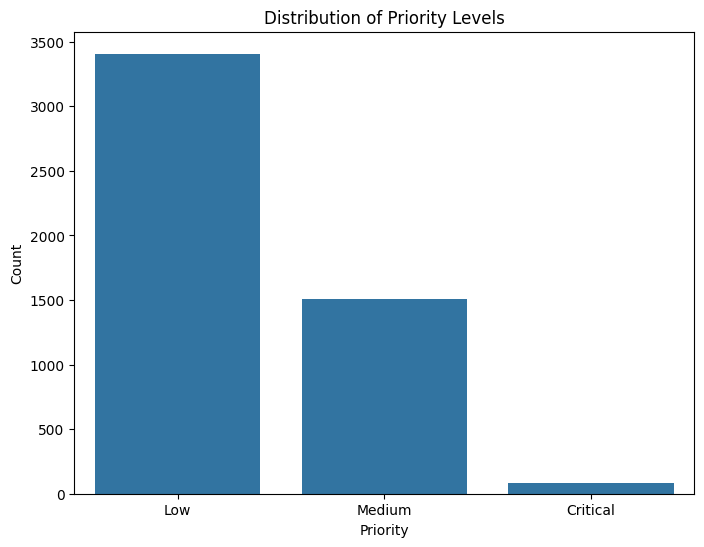

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(x='priority', data=df, order=df['priority'].value_counts().index)
plt.title('Distribution of Priority Levels')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.show()
plt.savefig('outputs/priority_distribution.png')
plt.close()